In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analyzing the probabilities after fine-tuning

Analyzing different fine-tuning probabilities from different runs through confusion matrices. Changed values such as learning rates in each run. 

<b> 5 hosts, max learning rate of 1e-5 </b>

In [14]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv")
df_1e = pd.read_csv(file_path)
df_1e

,Unnamed: 0,Cat,Chicken,European rabbit,Gray wolf,Human,Pig,y_true,itr
0,0,0.092565,0.154685,0.072600,0.173884,0.322611,0.183655,Human,0
1,1,0.413319,0.112904,0.113968,0.188249,0.064998,0.106563,Pig,0
2,2,0.492880,0.106734,0.093377,0.136344,0.080404,0.090262,Human,0
3,3,0.038249,0.136735,0.158560,0.180364,0.444808,0.041285,Human,0
4,4,0.099614,0.220222,0.065730,0.196319,0.233449,0.184666,Human,0
...,...,...,...,...,...,...,...,...,...
130,22,0.103008,0.164551,0.247137,0.027413,0.070135,0.387756,Chicken,4
131,23,0.015092,0.081642,0.101963,0.016482,0.541764,0.243057,Chicken,4
132,24,0.076392,0.624302,0.076234,0.035920,0.133933,0.053219,Human,4
133,25,0.025209,0.142712,0.335596,0.042261,0.386422,0.067800,Human,4


# Confusion Matrix

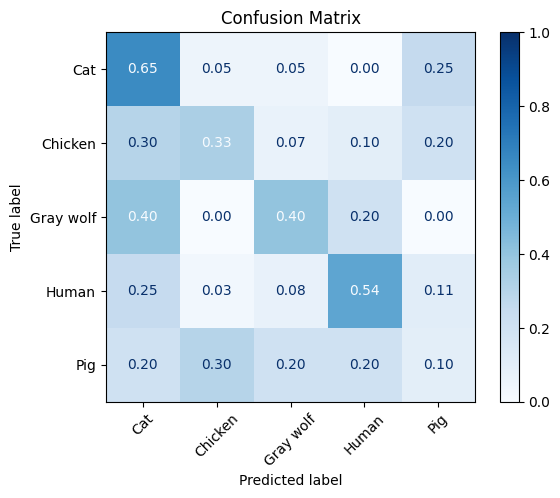

In [15]:
host_col = ['Cat', 'Chicken', 'Gray wolf', 'Human', 'Pig']
df_1e['y_pred'] = df_1e[host_col].idxmax(axis=1)

cm = confusion_matrix(df_1e['y_true'], df_1e['y_pred'], labels=host_col)
scale = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format = ".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix")
plt.show()

# Analysis

- cat and human are predicted pretty well, above average. Although, the model often mixes up almost everything for cat.
- For pig, it was not predicted correct even once.
- Wolf was correct on two occurrences, but cat was also predicted for wolf twice.
- Human was misclassified as Cat 15 times, which is a lot.
- The model seems to be weak, and this can be seen in the validation loss graph.

In [4]:
file_path = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
three_epoch50 = pd.read_csv(file_path)
three_epoch50

,Unnamed: 0,Cat,Chicken,Human,y_true,itr
0,0,0.186377,0.308808,0.504815,Human,0
1,1,0.581645,0.288343,0.130013,Human,0
2,2,0.610693,0.231999,0.157308,Cat,0
3,3,0.245026,0.220381,0.534593,Human,0
4,4,0.594781,0.250486,0.154733,Chicken,0
...,...,...,...,...,...,...
111,19,0.544317,0.343030,0.112654,Cat,4
112,20,0.239289,0.190376,0.570336,Human,4
113,21,0.535099,0.330008,0.134893,Chicken,4
114,22,0.661979,0.166963,0.171058,Human,4


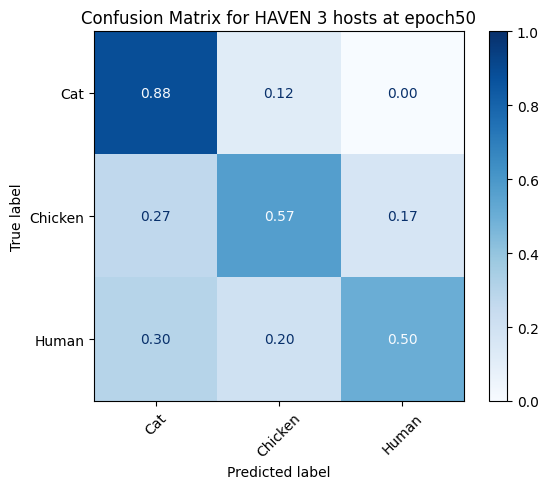

In [5]:
host_col = ['Cat', 'Chicken', 'Human']
three_epoch50['y_pred'] = three_epoch50[host_col].idxmax(axis=1)

cm = confusion_matrix(three_epoch50['y_true'], three_epoch50['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 3 hosts at epoch50")
plt.show()
#avg = 0.65

In [6]:
file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch50_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
four_epoch50 = pd.read_csv(file)
four_epoch50

,Unnamed: 0,Cat,Chicken,Human,Pig,y_true,itr
0,0,0.543642,0.180503,0.125740,0.150115,Chicken,0
1,1,0.517764,0.182204,0.122845,0.177187,Human,0
2,2,0.307592,0.216813,0.293070,0.182525,Human,0
3,3,0.227582,0.312660,0.321286,0.138472,Human,0
4,4,0.569490,0.159688,0.113517,0.157305,Cat,0
...,...,...,...,...,...,...,...
115,19,0.116485,0.277357,0.517686,0.088472,Chicken,4
116,20,0.087626,0.067690,0.672953,0.171731,Human,4
117,21,0.196160,0.135612,0.458033,0.210195,Human,4
118,22,0.077578,0.387879,0.181082,0.353461,Chicken,4


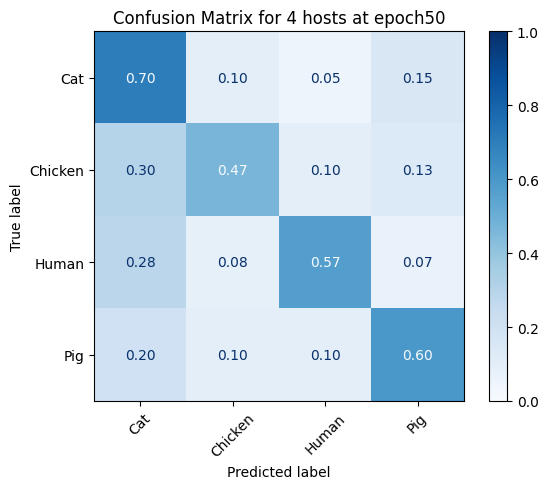

In [7]:
host_col = ['Cat', 'Chicken', 'Human', 'Pig']
four_epoch50['y_pred'] = four_epoch50[host_col].idxmax(axis=1)

cm = confusion_matrix(four_epoch50['y_true'], four_epoch50['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for 4 hosts at epoch50")
plt.show()

#avg = 0.585

In [8]:
file_path = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/3hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
three_epoch100 = pd.read_csv(file_path)
three_epoch100

,Unnamed: 0,Cat,Chicken,Human,y_true,itr
0,0,0.710859,0.197571,0.091570,Cat,0
1,1,0.678778,0.223366,0.097856,Human,0
2,2,0.603641,0.167346,0.229013,Human,0
3,3,0.451630,0.412266,0.136104,Chicken,0
4,4,0.144145,0.178665,0.677190,Human,0
...,...,...,...,...,...,...
113,19,0.094365,0.193073,0.712562,Human,4
114,20,0.045640,0.902047,0.052313,Chicken,4
115,21,0.186714,0.446014,0.367272,Human,4
116,22,0.739915,0.165242,0.094843,Human,4


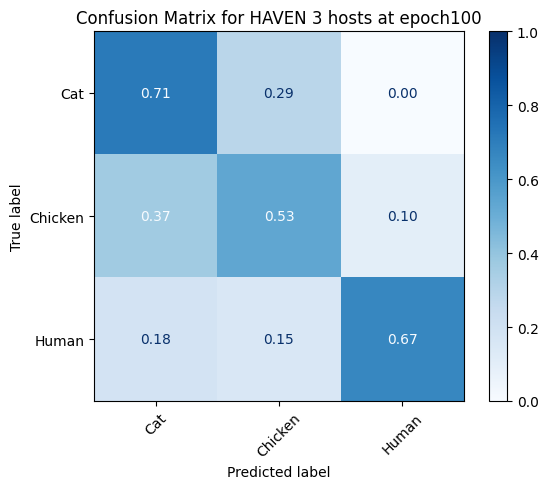

In [9]:
host_col = ['Cat', 'Chicken', 'Human']
three_epoch100['y_pred'] = three_epoch100[host_col].idxmax(axis=1)

cm = confusion_matrix(three_epoch100['y_true'], three_epoch100['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 3 hosts at epoch100")
plt.show()

#avg = 0.63666

In [10]:
file = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/new_experiments/4hosts_epoch100_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
four_epoch100 = pd.read_csv(file)
four_epoch100

,Unnamed: 0,Cat,Chicken,Human,Pig,y_true,itr
0,0,0.276477,0.099966,0.385942,0.237616,Human,0
1,1,0.208315,0.108457,0.567533,0.115696,Chicken,0
2,2,0.385500,0.053751,0.402790,0.157959,Human,0
3,3,0.689816,0.076376,0.085574,0.148234,Human,0
4,4,0.905892,0.033642,0.027738,0.032728,Cat,0
...,...,...,...,...,...,...,...
115,19,0.637931,0.077255,0.118297,0.166517,Human,4
116,20,0.155407,0.109007,0.416090,0.319496,Pig,4
117,21,0.427700,0.130447,0.114982,0.326871,Cat,4
118,22,0.042489,0.038182,0.686993,0.232335,Human,4


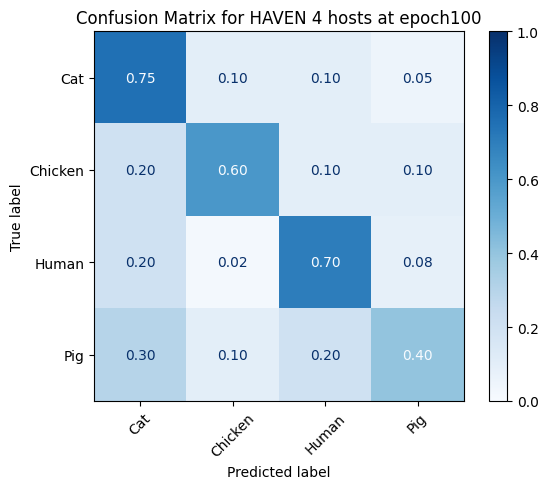

In [16]:
host_col = ['Cat', 'Chicken', 'Human', 'Pig']
four_epoch100['y_pred'] = four_epoch100[host_col].idxmax(axis=1)

cm = confusion_matrix(four_epoch100['y_true'], four_epoch100['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for HAVEN 4 hosts at epoch100")
plt.show()

#avg - 0.6125

# Analysis
<b> HAVEN performs best with 3 hosts and epoch50. It is a complex model that needs a substantial amount of data, and 3 hosts gives it more samples per host class to learn from, whereas 5 hosts has too little samples per host (wolf only has 17)

# 3 hosts at epoch50 vs. traditional MLMs

In [17]:
lr = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_lr_3hosts_lr_output.csv")
df_lr = pd.read_csv(lr)
df_lr

,Unnamed: 0,Cat,Chicken,Human,y_true,itr
0,0,0.890381,0.050505,0.059114,Cat,0
1,1,0.181184,0.318232,0.500584,Chicken,0
2,2,0.344262,0.166342,0.489396,Cat,0
3,3,0.093219,0.550345,0.356436,Chicken,0
4,4,0.010312,0.015520,0.974168,Human,0
...,...,...,...,...,...,...
215,39,0.375641,0.334921,0.289437,Human,4
216,40,0.120135,0.491773,0.388092,Human,4
217,41,0.035164,0.018211,0.946625,Human,4
218,42,0.722494,0.045922,0.231584,Human,4


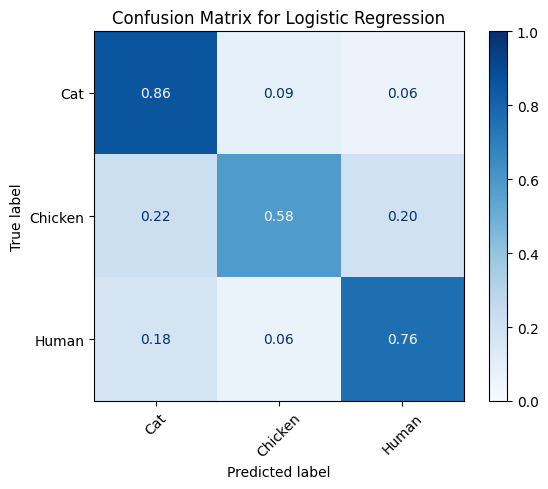

In [19]:
host_col = ['Cat', 'Chicken', 'Human']
df_lr['y_pred'] = df_lr[host_col].idxmax(axis=1)

cm = confusion_matrix(df_lr['y_true'], df_lr['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for Logistic Regression")
figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/visualization/uniref50/lr_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()

#avg 0.73

In [20]:
rf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_rf_3hosts_rf_output.csv")
df_rf = pd.read_csv(rf)
df_rf

,Unnamed: 0,Cat,Chicken,Human,y_true,itr
0,0,0.552361,0.183242,0.264398,Cat,0
1,1,0.279698,0.404429,0.315873,Chicken,0
2,2,0.441887,0.207675,0.350438,Cat,0
3,3,0.158324,0.696600,0.145076,Chicken,0
4,4,0.136631,0.307277,0.556092,Human,0
...,...,...,...,...,...,...
215,39,0.393666,0.275682,0.330652,Human,4
216,40,0.326673,0.302395,0.370932,Human,4
217,41,0.266408,0.186825,0.546768,Human,4
218,42,0.338063,0.203200,0.458737,Human,4


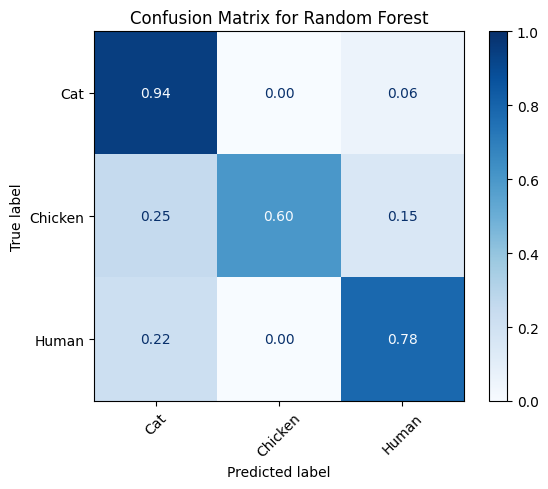

In [22]:
host_col = ['Cat', 'Chicken', 'Human']
df_rf['y_pred'] = df_rf[host_col].idxmax(axis=1)

cm = confusion_matrix(df_rf['y_true'], df_rf['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for Random Forest")

figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/visualization/uniref50/rf_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()
#avg 0.773

In [23]:
svm = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/kmer_k3_virus_host_tax_id_multi_svm_3hosts_svm_output.csv")
df_svm = pd.read_csv(svm)
df_svm

,Unnamed: 0,Cat,Chicken,Human,y_true,itr
0,0,0.653064,0.083425,0.263512,Cat,0
1,1,0.100755,0.591145,0.308100,Chicken,0
2,2,0.381316,0.096370,0.522315,Cat,0
3,3,0.065427,0.880691,0.053882,Chicken,0
4,4,0.029926,0.169039,0.801035,Human,0
...,...,...,...,...,...,...
215,39,0.227180,0.277743,0.495077,Human,4
216,40,0.087093,0.335245,0.577662,Human,4
217,41,0.058458,0.048226,0.893316,Human,4
218,42,0.242304,0.150991,0.606705,Human,4


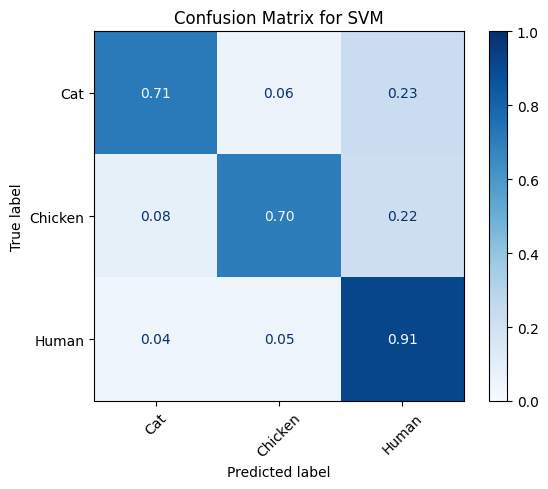

In [24]:
host_col = ['Cat', 'Chicken', 'Human']
df_svm['y_pred'] = df_svm[host_col].idxmax(axis=1)

cm = confusion_matrix(df_svm['y_true'], df_svm['y_pred'], labels=host_col)
scale = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=scale, display_labels=host_col)
disp.plot(xticks_rotation=45, cmap='Blues', values_format=".2f")
disp.im_.set_clim(0.0, 1.0)
plt.title("Confusion Matrix for SVM")
figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/visualization/uniref50/svm_confusionmatrix.pdf")
plt.savefig(figure_output_filepath, dpi=600)
plt.show()

#avg 0.773

# Analysis
<b> Both SVM and Random Forest have the highest probability average of 0.773. </b> The general machine learning models seem to perform better than HAVEN based on the probabilities resulted from fine-tuning. These models are not as complex as HAVEN, and don't need large datasets to make the most of their potential.